In [47]:
# try to mount google colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  cur_dir = "/content/drive/MyDrive/ws/prj/adv_ds_2310/Lab05_Models/ex01_iris_classification/preprocessing"
except:
  cur_dir = "."
  pass
cur_dir = os.path.abspath(cur_dir)
os.chdir(cur_dir)

print(f'cur_dir: {cur_dir} \n --> {os.path.abspath(".")}')

cur_dir: c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\NhomCSTTNT25-26\DuAn\eda 
 --> c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\NhomCSTTNT25-26\DuAn\eda


#### Khai báo thư viện

In [48]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import chi2_contingency
import math
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

#### Nạp dữ liệu

In [49]:
data_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]
data_path = "../data/banknote_authentication.csv"

df_dataset = pd.read_csv(data_path, names=data_names)

display.display(df_dataset)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [50]:
print(df_dataset.describe())

          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


#### Xóa dữ liệu trùng lặp

In [52]:
display.display(df_dataset[df_dataset.duplicated(keep = False)])

,variance,skewness,curtosis,entropy,class
21,0.3292,-4.4552,4.5718,-0.9888,0
41,-0.2062,9.2207,-3.7044,-6.8103,0
45,-0.7869,9.5663,-3.7867,-7.5034,0
47,-0.7869,9.5663,-3.7867,-7.5034,0
107,-1.8584,7.8860,-1.6643,-1.8384,0
119,0.9297,-3.7971,4.6429,-0.2957,0
139,-0.2062,9.2207,-3.7044,-6.8103,0
145,0.5195,-3.2633,3.0895,-0.9849,0
170,0.5706,-0.0248,1.2421,-0.5621,0
190,0.9297,-3.7971,4.6429,-0.2957,0


In [53]:
df_dataset.drop_duplicates(ignore_index=True, inplace=True)
display.display(df_dataset)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1343,0.40614,1.34920,-1.4501,-0.55949,1
1344,-1.38870,-4.87730,6.4774,0.34179,1
1345,-3.75030,-13.45860,17.5932,-2.77710,1
1346,-3.56370,-8.38270,12.3930,-1.28230,1


#### Biểu đồ cột Boxplot

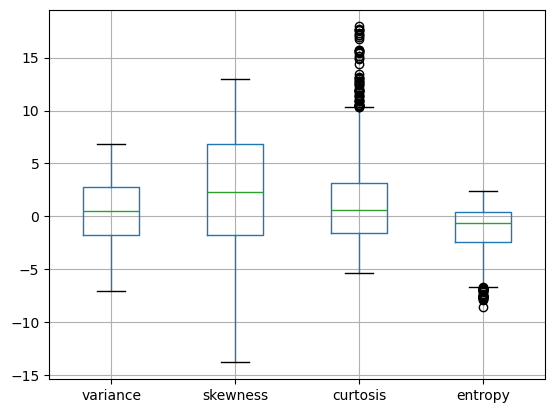

In [51]:
df_dataset.drop("class", axis=1).boxplot()
plt.show()

#### Biểu đồ Histogram

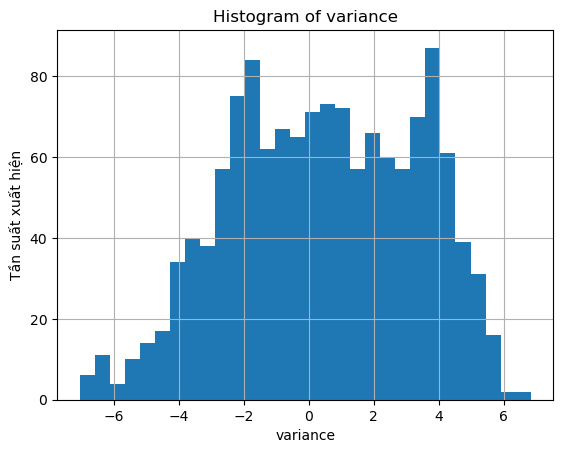

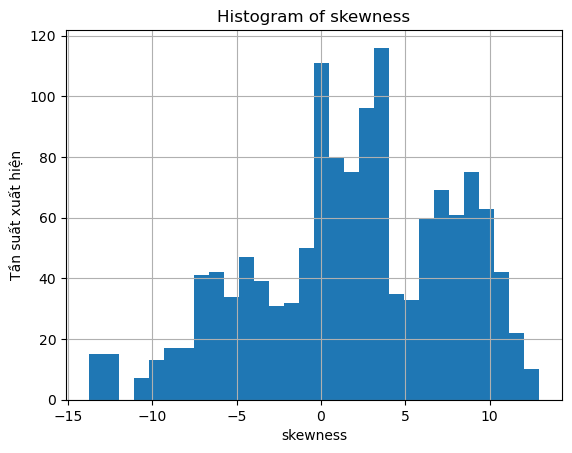

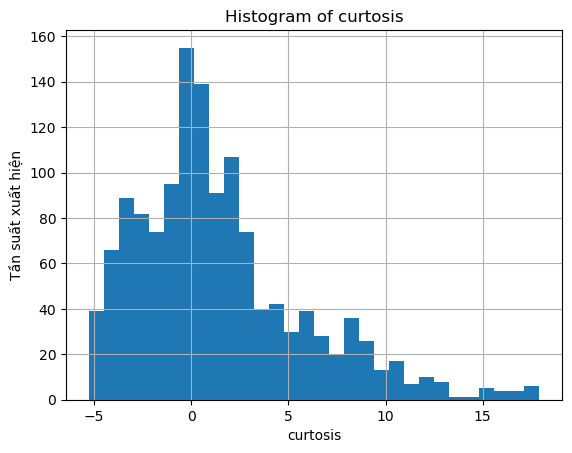

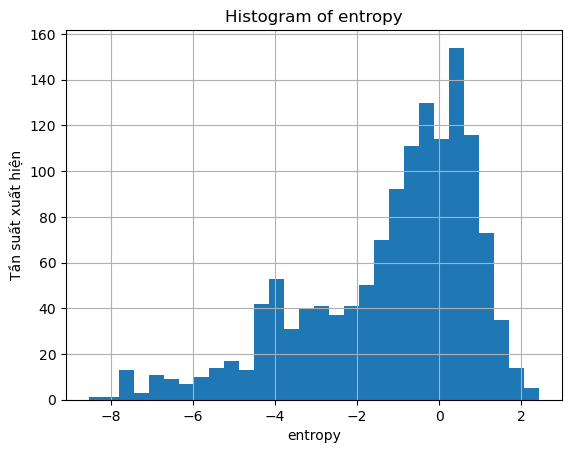

In [72]:
features = ["variance", "skewness", "curtosis", "entropy"]

for col in features:
    plt.figure()
    plt.hist(df_dataset[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất xuất hiện")
    plt.grid(True)
    plt.show()

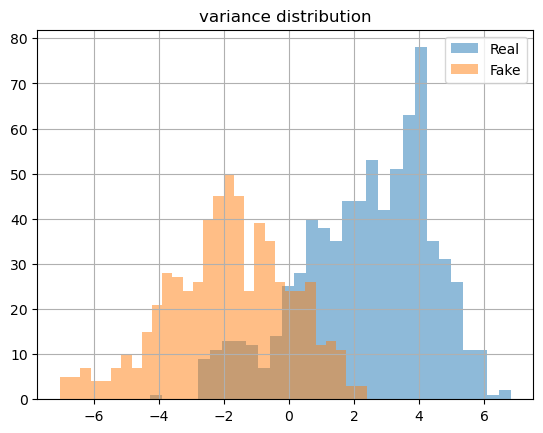

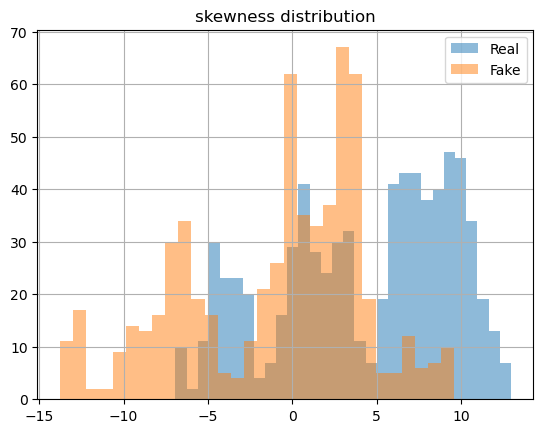

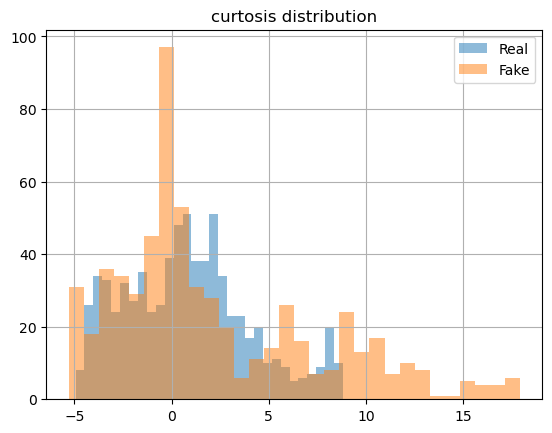

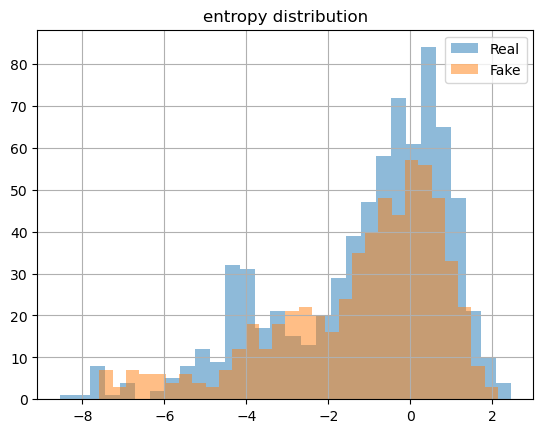

In [75]:
real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]
for col in features:
    plt.figure()
    plt.hist(real[col], bins=30, alpha=0.5, label="Real")
    plt.hist(fake[col], bins=30, alpha=0.5, label="Fake")
    plt.title(f"{col} distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

#### Ma trận tương quan

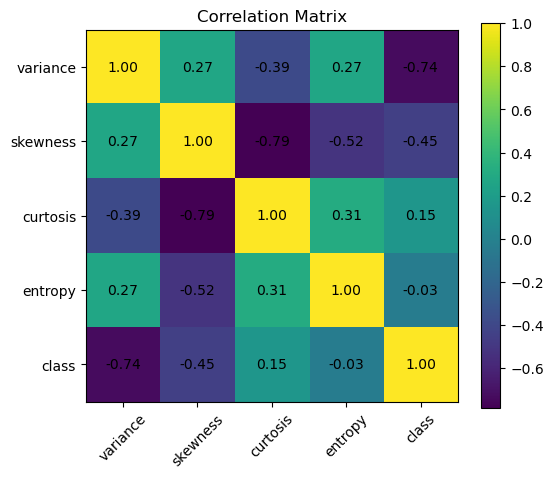

In [73]:
corr = df_dataset.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

ticks = np.arange(len(corr.columns))
plt.xticks(ticks, corr.columns, rotation=45)
plt.yticks(ticks, corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.show()

### Chia dữ liệu thực nghiệm

+ Dữ liệu ban đầu: chia 30% dữ liệu dùng để Test, 70% dùng để train

In [54]:
df = df_dataset.copy()

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 70% train, 30% test
    random_state=42,
    stratify=y          # giữ tỷ lệ class
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (943, 4)
Test size: (405, 4)


In [55]:
scaler = StandardScaler()

# fit trên train
X_train_scaled = scaler.fit_transform(X_train)

# transform test
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (943, 4)
Scaled test shape: (405, 4)


In [56]:
models = {
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# train tất cả models
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained")

kNN trained
Naive Bayes trained
SVM trained
Decision Tree trained
Random Forest trained
AdaBoost trained
Gradient Boosting trained
LDA trained
MLP trained
Logistic Regression trained


In [57]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        round(acc, 2),
        round(prec, 2),
        round(rec, 2),
        round(f1, 2),
        round(auc, 2)
    ])

# tạo bảng kết quả
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,kNN,1.00,0.99,1.00,1.00,1.00
2,SVM,1.00,0.99,1.00,1.00,1.00
4,Random Forest,1.00,0.99,1.00,1.00,1.00
6,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
3,Decision Tree,0.99,0.99,0.99,0.99,0.99
5,AdaBoost,0.99,0.98,1.00,0.99,1.00
7,LDA,0.99,0.97,1.00,0.99,1.00
8,MLP,0.99,0.97,1.00,0.99,1.00
9,Logistic Regression,0.99,0.97,1.00,0.99,1.00
1,Naive Bayes,0.87,0.85,0.86,0.86,0.95


In [58]:
param_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
print("Best SVM:", grid_svm.best_params_)

Best SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [59]:
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [60]:
param_knn = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
print("Best kNN:", grid_knn.best_params_)

Best kNN: {'n_neighbors': 3, 'weights': 'distance'}


In [61]:
param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train_scaled, y_train)

best_gb = grid_gb.best_estimator_
print("Best GB:", grid_gb.best_params_)

Best GB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [62]:
param_lr = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print("Best LR:", grid_lr.best_params_)

Best LR: {'C': 1, 'solver': 'lbfgs'}


In [63]:
tuned_models = {
    "SVM tuned": best_svm,
    "RF tuned": best_rf,
    "kNN tuned": best_knn,
    "GB tuned": best_gb,
    "LR tuned": best_lr
}

In [64]:
tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    tuned_results.append([
        name,
        round(acc, 2),
        round(prec, 2),
        round(rec, 2),
        round(f1, 2),
        round(auc, 2)
    ])

tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]
)

tuned_results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,SVM tuned,1.00,1.00,1.0,1.00,1.0
1,RF tuned,1.00,0.99,1.0,1.00,1.0
2,kNN tuned,1.00,0.99,1.0,1.00,1.0
3,GB tuned,1.00,1.00,1.0,1.00,1.0
4,LR tuned,0.99,0.97,1.0,0.99,1.0


In [65]:
comparison_df = pd.concat([results_df, tuned_results_df])
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,kNN,1.00,0.99,1.00,1.00,1.00
1,Naive Bayes,0.87,0.85,0.86,0.86,0.95
2,SVM,1.00,0.99,1.00,1.00,1.00
3,Decision Tree,0.99,0.99,0.99,0.99,0.99
4,Random Forest,1.00,0.99,1.00,1.00,1.00
5,AdaBoost,0.99,0.98,1.00,0.99,1.00
6,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
7,LDA,0.99,0.97,1.00,0.99,1.00
8,MLP,0.99,0.97,1.00,0.99,1.00
9,Logistic Regression,0.99,0.97,1.00,0.99,1.00


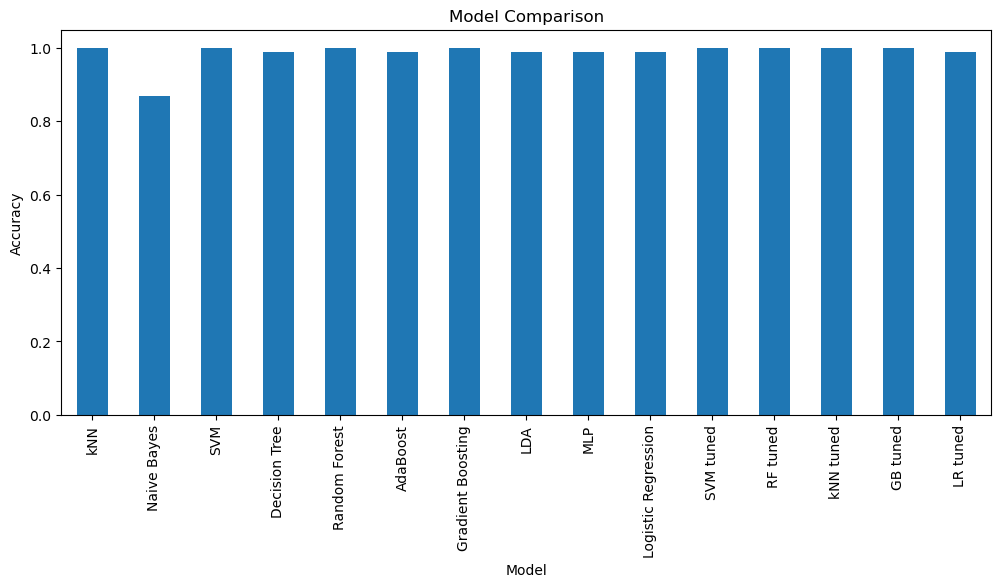

In [66]:
comparison_df.set_index("Model")["Accuracy"].plot(kind="bar", figsize=(12,5))
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()